<a href="https://colab.research.google.com/github/charlyacha/Labo1-colabs/blob/revisados/04_Buscando_la_ley_pendulo_photogate_y_ajuste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

<div align="center">

# 🔭 Colab 04 — Buscando la ley: el péndulo, el photogate y el primer ajuste

### *Del cronómetro al sensor, y del dato al modelo*

**Laboratorio 1 · Clase 4**

</div>

---

### 🎯 Objetivos de la clase

| # | Vas a aprender a... |
|---|---|
| O4.1, O4.2 | Extraer tiempos de evento de la señal cruda de un photogate |
| O4.3 | Asignar la incerteza temporal a partir de la frecuencia de muestreo |
| O4.4 | Comparar cuantitativamente el cronometrado manual contra el photogate |
| O4.5 | Ajustar por cuadrados mínimos, a mano y con `curve_fit` |
| O4.6 | **Determinar el exponente de la ley, sin suponerlo** |
| O4.7, O4.8 | Propagar al eje transformado por la linealización y graficar residuos siempre |
| O4.9, O4.10 | Obtener una primera determinación de $g$ y evaluar si el efecto de la amplitud es detectable |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import floor, log10

from scipy.optimize import curve_fit #Funcion de ajuste de datos

rng = np.random.default_rng(20260902) #Fijamos semilla para reproducibilidad

In [2]:
#Funciones heredadas de las clases anteriores
def reportar(x, dx, unidad=""):
    orden  = floor(log10(abs(dx)))
    cifras = 2 if int(dx / 10**orden) in (1, 2) else 1
    dec    = max(-(orden - (cifras - 1)), 0)
    return f"({x:.{dec}f} ± {dx:.{dec}f}) {unidad}".strip()

def compatibilidad(x1, dx1, x2, dx2, etiquetas=('1', '2')):
    z = abs(x1 - x2) / np.sqrt(dx1**2 + dx2**2)
    print(f"{etiquetas[0]}: {x1:.6g} ± {dx1:.2g}")
    print(f"{etiquetas[1]}: {x2:.6g} ± {dx2:.2g}")
    print(f"z = {z:.2f}")
    return z

---
## 1. La pregunta

Ignoremos que sabemos que $T = 2\pi\sqrt{L/g}$. La pregunta de hoy es más basica:

> **¿De qué depende el período de un péndulo, y con qué exponente?**

Suponemos que la relación tiene la forma de una **ley de potencias**,

$$ T = A\,L^{\,n} $$

y vamos a determinar $n$ **midiendo**.

> 🔑 **Concepto clave.** Si al final resulta $n = 0{,}50 \pm 0{,}01$, eso es un resultado
> experimental. Si escribimos la fórmula primero y después "verificamos" que $T^2$ es proporcional a
> $L$, no medimos el exponente: lo asumimos.

Para eso hace falta medir $T$ bien. Y ahí empieza el trabajo real de la clase.

---
## 2. El photogate: de $V(t)$ a tiempos de evento

El photogate es un par emisor–receptor. Cuando algo interrumpe el haz, la tensión del receptor
conmuta entre dos niveles.

> 🔑 **Lo que se adquiere es $V(t)$ muestreado**, no tiempos: los tiempos hay que extraerlos, y ése
> es el trabajo de esta sección.

La celda de abajo genera una señal cruda realista. **Cuando tengas tu archivo del Pasco, reemplazala
por `np.loadtxt`** — con dos columnas, tiempo y tensión.

In [3]:
path_datos = 'Archivos_salida/'

def señal_photogate(T_periodo, n_periodos, ancho_bloqueo=0.020, jitter=1.5e-4, 
                    seed=0, f_s=10000, V_alto=5.0, V_bajo=0.2):
    '''Genera V(t): 5 V libre, 0,2 V bloqueado. El péndulo bloquea DOS veces por período.'''
    r = np.random.default_rng(seed)
    t = np.arange(0, n_periodos * T_periodo + 0.5, 1/f_s)
    V = np.full_like(t, V_alto)
    # cruces por el punto más bajo: uno cada medio período
    k = np.arange(0, 2 * n_periodos + 1)
    t_cruce = 0.25 * T_periodo + k * T_periodo / 2 + r.normal(0, jitter, len(k))
    for tc in t_cruce:
        V[(t > tc - ancho_bloqueo/2) & (t < tc + ancho_bloqueo/2)] = V_bajo
    V = V + r.normal(0, 0.05, len(t))          # ruido electrónico
    return t, V

t_sig, V_sig = señal_photogate(T_periodo=1.4185, n_periodos=20, seed=1)
np.savetxt(path_datos + 'photogate_L050.txt', np.c_[t_sig, V_sig], fmt='%.5f')

288700 muestras, f_s = 1000 Hz, duración = 28.87 s


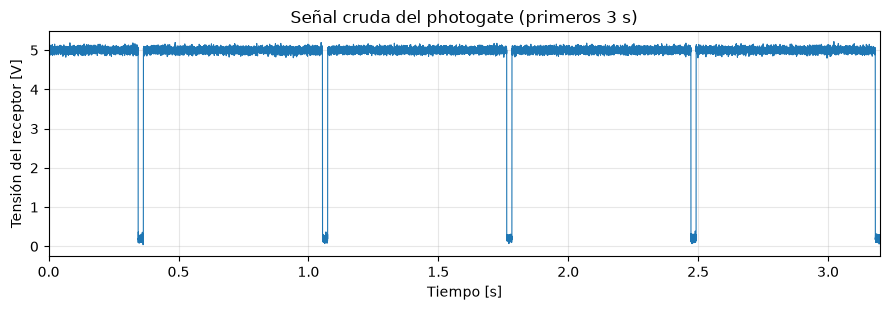

In [4]:
# ============ SEÑAL DE EJEMPLO — REEMPLAZAR POR EL ARCHIVO DEL PHOTOGATE ============
datos = np.loadtxt(path_datos + 'photogate_L050.txt')

f_s = 1000.0            # Hz — frecuencia de muestreo. CAMBIALA por la de tu adquisición.
V_alto, V_bajo = 5.0, 0.2

t_sig, V_sig = datos[:, 0], datos[:, 1]

plt.figure(figsize=(9, 3.2))
plt.plot(t_sig, V_sig, lw=0.8)
plt.xlim(0, 3.2)
plt.xlabel('Tiempo [s]'); plt.ylabel('Tensión del receptor [V]')
plt.title('Señal cruda del photogate (primeros 3 s)')
plt.grid(alpha=0.3)
plt.tight_layout()

print(f"{len(t_sig)} muestras, f_s = {f_s:.0f} Hz, duración = {t_sig[-1]:.2f} s")

### 2.1 El umbral

Hay que decidir a qué tensión se considera que el haz se interrumpió. La elección razonable es
**a mitad de camino entre los dos niveles**, y se declara en el informe.

⚠️ ¿Que ocurre si pongo una cota muy baja o muy alta?. Probalo en el Ejercicio 4.1.

In [5]:
umbral = (V_alto + V_bajo) / 2
print(f"umbral = {umbral:.2f} V")

# bloqueado = señal por debajo del umbral
bloqueado = V_sig < umbral

# caidas/subidas: donde cambia el estado
cambios = np.diff(bloqueado.astype(int))
i_bajada = np.where(cambios ==  1)[0]     # empieza el bloqueo
i_subida = np.where(cambios == -1)[0]     # termina el bloqueo

print(f"Caidas de tension: {len(i_bajada)}   Subidas de tension: {len(i_subida)}")

umbral = 2.60 V
Caidas de tension: 41   Subidas de tension: 41


### 2.2 El criterio de corte

Cada interrupción produce **dos** flancos: uno cuando el objeto entra al haz y otro cuando sale. Hay
que elegir **uno solo** y usar siempre el mismo.

⚠️ ¿Por qué importa? Porque el ancho del bloqueo depende de la velocidad con que pasa el péndulo, y
esa velocidad depende de la amplitud, que **decae** durante la medición. Si mezclás flancos de
entrada y de salida, ese decaimiento se te mete adentro del período medido y aparece como una deriva
que no existe.

Elegimos el flanco de **bajada** (entrada al haz) y lo declaramos.

In [6]:
def tiempos_de_flanco(t, V, umbral, tipo='bajada'):
    '''Devuelve los instantes en que V cruza el umbral, interpolando entre muestras.'''
    # Convertimos la tension en una señal logica: 
    # 1 cuando el haz esta bloqueado, 0 cuando esta libre.
    b = (V < umbral).astype(int) # booleano convertido a 0 y 1

    # La diferencia vale +1 al comenzar un bloqueo y -1 al terminarlo.
    d = np.diff(b)

    # Seleccionamos los indices de los cambios que corresponden al tipo de flanco elegido.
    idx = np.where(d == (1 if tipo == 'bajada' else -1))[0]

    # Tomamos las dos muestras que encierran cada cruce del umbral.
    V0, V1 = V[idx], V[idx + 1]
    t0, t1 = t[idx], t[idx + 1]

    # fraccion indica que parte del intervalo temporal hay que recorrer desde t0
    # para llegar al umbral, suponiendo que V cambia linealmente entre las muestras.
    frac = (umbral - V0) / (V1 - V0)
    return t0 + frac * (t1 - t0)

# Detectamos solo los flancos de bajada, es decir, las entradas al haz.
t_ev = tiempos_de_flanco(t_sig, V_sig, umbral, 'bajada')
print(f"{len(t_ev)} eventos detectados")
print("primeros cinco [s]:", np.round(t_ev[:5], 4))

41 eventos detectados
primeros cinco [s]: [0.3446 1.054  1.7632 2.4721 3.1818]


### 2.3 La trampa: dos interrupciones por período

⚠️ Acá está el error más frecuente de la clase, y conviene cometerlo antes de que se lo adviertan.

El péndulo pasa por el punto más bajo **dos veces por ciclo**: una de ida y otra de vuelta. La
diferencia entre dos flancos consecutivos es **medio** período, no uno.

In [7]:
dt = np.diff(t_ev)

print("MAL — tomando diferencias consecutivas:")
T_mal = dt.mean()
print(f"   T = {T_mal:.4f} s   ->  g = {4*np.pi**2*0.500/T_mal**2:.2f} m/s²  (con L = 0,500 m)")

print("\nBIEN — un período son DOS interrupciones:")
T_ok = 2 * dt.mean()
print(f"   T = {T_ok:.4f} s   ->  g = {4*np.pi**2*0.500/T_ok**2:.2f} m/s²")

MAL — tomando diferencias consecutivas:
   T = 0.7092 s   ->  g = 39.24 m/s²  (con L = 0,500 m)

BIEN — un período son DOS interrupciones:
   T = 1.4185 s   ->  g = 9.81 m/s²


Un factor 2 en el período es un factor **4** en $g$. El resultado equivocado no es "un poco distinto":
es absurdo, y por eso se detecta.

> 🔑 La moraleja es la de siempre: **calculá la magnitud física, no te quedes en el ajuste**, porque
> el número físico tiene un valor esperado y el parámetro del ajuste no.

Hay una forma más robusta de hacerlo, que además usa toda la información:

In [8]:
# Tomamos flancos alternados: eso da un período completo cada vez
T_individuales = np.diff(t_ev[::2]) #Tomo los elementos de la lista salteando uno en medio siempre

print(f"períodos medidos: {len(T_individuales)}")
print(f"T medio     = {T_individuales.mean():.5f} s")
print(f"dispersión  = {np.std(T_individuales, ddof=1):.5f} s")

períodos medidos: 20
T medio     = 1.41849 s
dispersión  = 0.00023 s


### 2.4 La incerteza del tiempo, y de dónde sale

El instante del cruce se conoce con una indeterminación fijada por el **muestreo**: entre dos
muestras consecutivas no hay información. Ese error es **uniforme** en un intervalo de ancho
$\Delta t_s = 1/f_s$, y ya sabés cuánto vale su desviación estándar (Colabs 01 y 03):

$$ \sigma_t = \frac{\Delta t_s}{\sqrt{12}} $$

Un período se obtiene como diferencia de **dos** flancos, así que $\sigma_T = \sigma_t\sqrt{2}$. Y si
medís sobre $N$ períodos y dividís, $\sigma_T = \sigma_t\sqrt{2}/N$ — el mismo $1/N$ del faro de la
Clase 3, ahora con electrónica en lugar de pulgar.

> 🔑 **Pero ése es un piso, no la respuesta.** Vale la regla de la Clase 1: la incerteza es **la
> mayor** entre la resolución y la dispersión observada al repetir.

In [9]:
# Incertidumbre de un único instante de cruce, debida sólo a la resolución temporal.
sigma_t = (1/f_s) / np.sqrt(12)
N_per   = len(T_individuales)

# Incerteza de restar dos instantes de cruce.
sigma_T_muestreo   = sigma_t * np.sqrt(2)

# Dispersión de los períodos medidos: incluye variaciones reales y efectos sistemáticos,
# además del muestreo. No es la incertidumbre de una muestra, sino la variabilidad observada
# al repetir la medición en distintos períodos.
sigma_T_dispersion = np.std(T_individuales, ddof=1)

print(f"σ_t (muestreo)                        = {sigma_t*1e6:.1f} µs")
print(f"σ_T por muestreo, un período          = {sigma_T_muestreo*1e6:.1f} µs")
print(f"σ_T por dispersión observada          = {sigma_T_dispersion*1e6:.1f} µs")
print()
sigma_T_1 = max(sigma_T_muestreo, sigma_T_dispersion)
print(f"-> se adopta σ_T (un período) = {sigma_T_1*1e6:.1f} µs   "
      f"({'dispersión' if sigma_T_dispersion > sigma_T_muestreo else 'muestreo'})")

# y el promedio sobre los N períodos medidos
T_photogate = T_individuales.mean()
sigma_T_photogate = sigma_T_1 / np.sqrt(N_per)
print(f"\nT (photogate, {N_per} períodos) = {reportar(T_photogate, sigma_T_photogate, 's')}")

σ_t (muestreo)                        = 288.7 µs
σ_T por muestreo, un período          = 408.2 µs
σ_T por dispersión observada          = 227.1 µs

-> se adopta σ_T (un período) = 408.2 µs   (muestreo)

T (photogate, 20 períodos) = (1.41849 ± 0.00009) s


Si la dispersión gana por mucho, el muestreo **no es tu limitación**: lo que limita es el péndulo
(corrientes de aire, rozamiento en el pivote, decaimiento de la amplitud). Subir la frecuencia de
muestreo no mejoraría nada. Es otra vez la tabla de contribuciones del Colab 02, en otro disfraz.

> **✏️ Ejercicio 4.1.** Cambiá `umbral` a 4,5 V (cerca del nivel alto) y volvé a correr la detección.
> ¿Cuántos eventos detecta ahora? ¿De dónde salen los de más? Después probá con 0,5 V.

---
## 3. Pulgar contra photogate

La conclusión de la Clase 3 fue que en algún punto conviene dejar de repetir y **cambiar el método**.
Acá está el número.

In [10]:
# --- Cronometrado manual: 5 tandas de 20 períodos (REEMPLAZAR POR LOS PROPIOS) ---
T_real = 1.4185
manual_totales = 20 * T_real + rng.normal(0, 0.17, 5)     # σ_evento del cronómetro, Clase 3
T_manual = manual_totales.mean() / 20
sigma_T_manual = 0.17 / (20 * np.sqrt(5))
# ---------------------------------------------------------------------------------

print("Manual, 5 tandas de 20 :", reportar(T_manual, sigma_T_manual, 's'))
print("Photogate              :", reportar(T_photogate, sigma_T_photogate, 's'))
print(f"\nEl photogate es {sigma_T_manual/sigma_T_photogate:.0f} veces más preciso, "
      f"con el mismo tiempo de mesada")
print()
_ = compatibilidad(T_manual, sigma_T_manual, T_photogate, sigma_T_photogate,
                   ('manual', 'photogate'))

Manual, 5 tandas de 20 : (1.415 ± 0.004) s
Photogate              : (1.41849 ± 0.00009) s

El photogate es 42 veces más preciso, con el mismo tiempo de mesada

manual: 1.41476 ± 0.0038
photogate: 1.41849 ± 9.1e-05
z = 0.98


---
## 4. Cuadrados mínimos

Tenemos pares $(x_i, y_i)$ y proponemos $y = a x + b$. El criterio elige $a$ y $b$ que minimizan

$$ S(a,b) = \sum_{i=1}^{N} \left[y_i - (a x_i + b)\right]^2 $$

### ⚠️ Dos cosas antes de apretar el botón

- Supone que **el error está en $y$** y que $x$ se conoce mucho mejor. Vamos a tener que verificarlo
  hoy mismo, y la respuesta va a ser incómoda.
- Supone que **todos los puntos tienen la misma incerteza**. Casi nunca es cierto; se arregla en el
  Colab 06.

Lo implementamos una vez a mano, para que la caja no arranque negra.

In [11]:
def cuadrados_minimos(x, y):
    '''Ajuste lineal no ponderado. Devuelve (a, b, sigma_a, sigma_b, s_y).'''
    x, y = np.asarray(x, float), np.asarray(y, float)
    N = len(x)
    Sx, Sy   = x.sum(), y.sum()
    Sxx, Sxy = (x*x).sum(), (x*y).sum()
    Delta = N*Sxx - Sx**2
    a = (N*Sxy - Sx*Sy) / Delta            # pendiente
    b = (Sxx*Sy - Sx*Sxy) / Delta          # ordenada al origen
    residuos = y - (a*x + b)
    s_y = np.sqrt((residuos**2).sum() / (N - 2))    # N-2: dos parámetros ajustados
    return a, b, s_y*np.sqrt(N/Delta), s_y*np.sqrt(Sxx/Delta), s_y

def recta(x, a, b):
    return a*x + b

### 📊 La figura estándar del curso

De acá en adelante, **todo ajuste de este curso se grafica junto con sus residuos**.

> 🔑 El residuo del punto $i$ es $r_i = y_i - f(x_i)$, y si el modelo es adecuado deben verse como
> ruido alrededor de cero: sin estructura, sin tendencia, sin curvatura. Cualquier patrón visible es
> el modelo diciéndote que le falta algo.

In [12]:
def grafico_con_residuos(x, y, modelo, popt, yerr=None, xerr=None,
                         xlabel='x', ylabel='y', titulo='', etiqueta_modelo='ajuste',
                         logx=False, logy=False):
    '''Figura estándar del curso: datos + modelo arriba, residuos abajo.'''
    x, y = np.asarray(x, float), np.asarray(y, float)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.6), sharex=True,
                                   gridspec_kw={'height_ratios': [3, 1]})
    xx = np.linspace(x.min(), x.max(), 400)
    ax1.errorbar(x, y, yerr=yerr, xerr=xerr, fmt='o', ms=5, capsize=3, label='datos')
    ax1.plot(xx, modelo(xx, *popt), 'crimson', lw=1.8, label=etiqueta_modelo)
    ax1.set_ylabel(ylabel); ax1.set_title(titulo, fontsize=11)
    ax1.grid(alpha=0.3); ax1.legend()

    r = y - modelo(x, *popt)
    ax2.axhline(0, color='k', lw=1)
    ax2.errorbar(x, r, yerr=yerr, fmt='o', ms=5, capsize=3)
    ax2.set_xlabel(xlabel); ax2.set_ylabel('residuos')
    ax2.grid(alpha=0.3)
    if logx: ax1.set_xscale('log'); ax2.set_xscale('log')
    if logy: ax1.set_yscale('log')
    fig.tight_layout()
    return fig, (ax1, ax2)

---
## 5. Buscar el exponente

Ahora los datos de la clase: el período para 7 longitudes distintas, con amplitud chica y **fija**.

In [13]:
# ============ DATOS DE EJEMPLO — REEMPLAZAR POR LOS PROPIOS ============
g_BsAs = 9.7967                                    # m/s², valor local de referencia
L      = np.array([0.200, 0.300, 0.450, 0.600, 0.750, 0.900, 1.100])   # m, lo que ANOTASTE
sigma_L = 0.001                                   # m — el punto flojo, ver más abajo

# La longitud efectiva real difiere de la anotada: el hilo se estira, el centro de masa de la
# esfera no está donde uno cree. Eso es lo que sigma_L representa.
L_efectiva = L + rng.normal(0, sigma_L, len(L))
T = 2*np.pi*np.sqrt(L_efectiva/g_BsAs) * (1 + rng.normal(0, 8e-5, len(L)))
sigma_T = np.full(len(L), sigma_T_photogate)
np.savetxt(path_datos + 'pendulo_T_vs_L.txt', np.c_[L, T, sigma_T], fmt='%.6f')

In [14]:
L, T, sigma_T = np.loadtxt(path_datos + 'pendulo_T_vs_L.txt', unpack=True)
for l_, t_, s_ in zip(L, T, sigma_T):
    print(f"L = {l_:.3f} m   T = {reportar(t_, s_, 's')}")

L = 0.200 m   T = (0.89715 ± 0.00009) s
L = 0.300 m   T = (1.10198 ± 0.00009) s
L = 0.450 m   T = (1.34594 ± 0.00009) s
L = 0.600 m   T = (1.55247 ± 0.00009) s
L = 0.750 m   T = (1.73642 ± 0.00009) s
L = 0.900 m   T = (1.90373 ± 0.00009) s
L = 1.100 m   T = (2.10339 ± 0.00009) s


### 5.1 Antes de ajustar: ¿el error esta en $y$ realmente?

Cuadrados mínimos supone que $x$ se conoce mucho mejor que $y$. Verifiquémoslo, porque hoy tenemos un
photogate y la situación cambió.

El criterio es comparar $\sigma_x \left|\dfrac{dy}{dx}\right|$ contra $\sigma_y$. Si el primero gana,
el error dominante **no está donde el método supone**.

In [15]:
dT_dL = np.pi / np.sqrt(g_BsAs * L)        # derivada de T = 2π√(L/g)
efecto_L = sigma_L * dT_dL

print(f"{'L [m]':>7s} {'σ_T (photogate)':>18s} {'σ_L·|dT/dL|':>14s} {'domina':>12s}")
print("-" * 56)
for l_, sT, eL in zip(L, sigma_T, efecto_L):
    print(f"{l_:7.3f} {sT*1e6:15.0f} µs {eL*1e6:11.0f} µs "
          f"{'LONGITUD' if eL > sT else 'tiempo':>12s}")

# incerteza efectiva: se suman en cuadratura (propagación, Colab 02)
sigma_T_ef = np.sqrt(sigma_T**2 + efecto_L**2)
print(f"\nσ_T efectiva [µs]: {np.round(sigma_T_ef*1e6, 0)}")

  L [m]    σ_T (photogate)    σ_L·|dT/dL|       domina
--------------------------------------------------------
  0.200              91 µs        2244 µs     LONGITUD
  0.300              91 µs        1833 µs     LONGITUD
  0.450              91 µs        1496 µs     LONGITUD
  0.600              91 µs        1296 µs     LONGITUD
  0.750              91 µs        1159 µs     LONGITUD
  0.900              91 µs        1058 µs     LONGITUD
  1.100              91 µs         957 µs     LONGITUD

σ_T efectiva [µs]: [2246. 1835. 1499. 1299. 1163. 1062.  961.]


> 🔑 **Éste es el resultado más importante de la clase.** Con el photogate,
> la incerteza dominante ya no es el tiempo: es la **longitud**. Mejorar la adquisición no serviría
> de nada; definir mejor dónde empieza y termina el péndulo, sí. (¿Hasta el centro de la esfera?
> ¿Hasta dónde está anudado el hilo? ¿Cuánto se estira el hilo con la carga?)

Es la misma lección de la tabla de contribuciones del Colab 02, ahora en un contexto de ajuste. El
cuello de botella se movió, y hay que ir a buscarlo donde está.

La solución práctica —legítima mientras la relación sea localmente lineal— es convertir la incerteza
en $x$ en una incerteza equivalente en $y$ y sumarla en cuadratura, que es lo que acabamos de hacer.

> **📌 Entonces, ¿para qué el photogate?** Pregunta legítima, y la respuesta no es "porque sí". Para
> este experimento —$T$ contra $L$— casi no cambia el resultado, porque el cuello de botella está en
> la longitud. **Pero en el experimento de la Sección 7 la longitud es fija**, así que se cancela por
> completo y la única incerteza que queda es la del tiempo. Ahí el photogate no es un lujo: es la
> diferencia entre poder medir el efecto de la amplitud y no poder.
>
> Ésa es una lección de diseño experimental que conviene retener: **la utilidad de un instrumento no
> se juzga en abstracto, sino contra el resto del presupuesto de error del experimento concreto.**

### 5.2 El ajuste log-log

$$ T = A\,L^{\,n} \quad \Longrightarrow \quad \ln T = \ln A + n \ln L $$

⚠️ La transformación también transforma las barras: si $y' = \ln y$, entonces
$\sigma_{y'} = \sigma_y / y$. **Puntos con la misma barra absoluta terminan con barras logarítmicas
muy distintas.** Hay que propagarlas, no arrastrarlas.

exponente  n = (0.4991 ± 0.0008)
ln A         = 0.69585 ± 0.00070

¿es compatible con n = 1/2?   z = 1.10  ->  sí


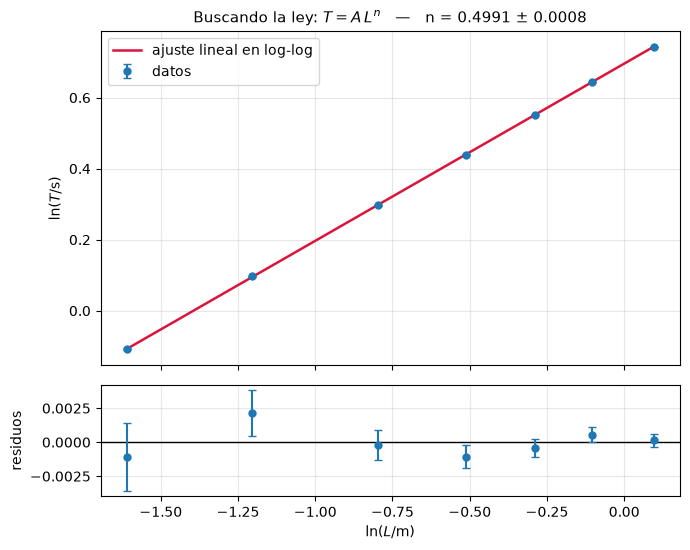

In [16]:
lnL, lnT = np.log(L), np.log(T)
sigma_lnT = sigma_T_ef / T                 # <- la propagación que hay que hacer

n_hat, lnA, sn, slnA, _ = cuadrados_minimos(lnL, lnT)

print(f"exponente  n = {reportar(n_hat, sn, '')}")
print(f"ln A         = {lnA:.5f} ± {slnA:.5f}")
print()
z = abs(n_hat - 0.5) / sn
print(f"¿es compatible con n = 1/2?   z = {z:.2f}  ->  "
      f"{'sí' if z < 2 else 'NO — revisar'}")

fig, _ = grafico_con_residuos(lnL, lnT, recta, (n_hat, lnA), yerr=sigma_lnT,
                              xlabel='$\\ln(L/\\mathrm{m})$', ylabel='$\\ln(T/\\mathrm{s})$',
                              titulo=f'Buscando la ley: $T = A\\,L^n$   —   n = {n_hat:.4f} ± {sn:.4f}',
                              etiqueta_modelo='ajuste lineal en log-log')

> 🔑 **El exponente salió de la medición.** Ése es el sentido de "buscar la ley": no verificamos una
> fórmula, determinamos un número que la fórmula predice.

Mirá el panel de residuos. Si aparece curvatura, el modelo de potencia pura no alcanza y hay que
sospechar de algo sistemático — típicamente, una longitud efectiva mal definida (que agrega un
$L_0$ constante y rompe la ley de potencias pura).

> **✏️ Ejercicio 4.2.** Agregale 5 mm a todas tus longitudes (simulando que medías hasta la parte de
> arriba de la esfera en lugar del centro) y volvé a ajustar. ¿Cuánto cambia $n$? ¿Se sale de
> compatibilidad con 1/2? ¿Y qué pasa con los residuos?

---
## 6. De la ley al número: una primera determinación de $g$

Ahora que $n$ resultó compatible con 1/2, **podemos** usar la forma teórica.

> 🔑 Es importante el orden: primero la evidencia, después el modelo.

$$ T^2 = \frac{4\pi^2}{g}\,L \quad \Longrightarrow \quad g = \frac{4\pi^2}{\text{pendiente}} $$

Y otra vez hay que propagar al eje transformado: si $y = T^2$, entonces $\sigma_y = 2T\,\sigma_T$.

pendiente = 4.0192 ± 0.0049 s²/m
ordenada  = 0.00314 ± 0.00332 s²   (esperada: 0 si la longitud efectiva es la que medimos)

g medido    : (9.822 ± 0.012) m/s²
g referencia: 9.7967 m/s² (Buenos Aires)

g del péndulo: 9.82246 ± 0.012
g de referencia: 9.7967 ± 0.0001
z = 2.17


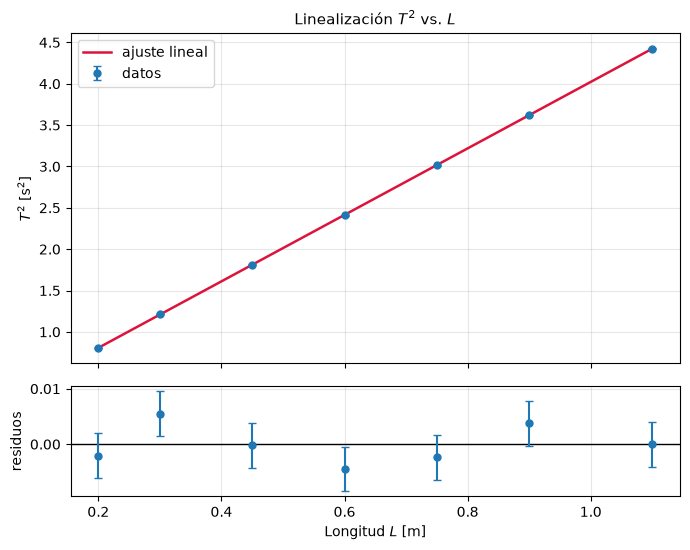

In [17]:
T2 = T**2
sigma_T2 = 2 * T * sigma_T_ef

pend, ordn, spend, sordn, _ = cuadrados_minimos(L, T2)

g_med  = 4*np.pi**2 / pend
sigma_g = g_med * (spend / pend)

print(f"pendiente = {pend:.4f} ± {spend:.4f} s²/m")
print(f"ordenada  = {ordn:.5f} ± {sordn:.5f} s²   "
      f"(esperada: 0 si la longitud efectiva es la que medimos)")
print()
print("g medido    :", reportar(g_med, sigma_g, 'm/s²'))
print("g referencia:", f"{g_BsAs} m/s² (Buenos Aires)")
print()
_ = compatibilidad(g_med, sigma_g, g_BsAs, 0.0001, ('g del péndulo', 'g de referencia'))

fig, _ = grafico_con_residuos(L, T2, recta, (pend, ordn), yerr=sigma_T2,
                              xlabel='Longitud $L$ [m]', ylabel='$T^2$ [s$^2$]',
                              titulo='Linealización $T^2$ vs. $L$',
                              etiqueta_modelo='ajuste lineal')

> **📌 Mirá la ordenada al origen.** Debería ser compatible con cero. Si no lo es, hay una longitud
> constante que no estás contando: $T^2 = (4\pi^2/g)(L + L_0)$ con $L_0 \ne 0$. Eso es un
> **sistemático** y el ajuste te lo está mostrando. Es el mismo tipo de diagnóstico que vas a hacer
> con el resorte la clase que viene.

> ⚠️ **Y sobre el valor de $g$ mismo.** Con los datos de ejemplo el resultado queda a algo más de
> $2\sigma$ del valor local. Ésa es exactamente la zona ambigua: demasiado lejos para ignorarlo,
> demasiado cerca para afirmar que hay un sistemático. Y **con las herramientas de hoy no se puede
> decidir**, porque el ajuste no ponderado estima la incerteza de los parámetros a partir de la
> dispersión de los residuos y no de tus barras de error: te devuelve una incerteza que describe cuán
> alineados están tus puntos, no cuán bien mediste. Para distinguir "fluctuación" de "sistemático"
> hace falta el ajuste ponderado y el $\chi^2$ reducido, que son la Clase 6. Dejalo anotado en el
> cuaderno; en la Clase 8 vas a volver sobre $g$ con las herramientas completas.

> **✏️ Ejercicio 4.3.** Compará tu $g$ con el que obtuviste propagando en el Ejercicio 2.5 del Colab
> 02 (un solo par $L$, $T$). ¿Cuál tiene menor incerteza? ¿Por qué siete puntos y un ajuste ganan
> contra una medición cuidadosa?

---
## 7. Segundo objetivo: ¿el período depende de la amplitud?

La aproximación de ángulos chicos no es exacta. El desarrollo del período real es

$$ T(\theta_0) = T_0\left(1 + \frac{\theta_0^2}{16} + \cdots\right) $$

con $\theta_0$ en radianes. A 20° eso es $+0{,}76\,\%$; a 40°, $+3\,\%$.

> 🔑 La pregunta **no** es si el efecto existe. La pregunta es **si tu método lo resuelve**.

In [18]:
# ¿Qué precisión hace falta?
theta_deg = np.array([5, 10, 15, 20, 25, 30, 35, 40])
theta = np.deg2rad(theta_deg)
correccion = theta**2 / 16

print(f"{'θ [°]':>6s} {'ΔT/T teórico':>14s} {'ΔT [µs]':>11s} {'¿supera σ_T?':>14s}")
print("-" * 50)
for td, cc in zip(theta_deg, correccion):
    dT = cc * T_photogate
    print(f"{td:6.0f} {100*cc:13.3f}% {dT*1e6:10.0f} {'sí' if dT > sigma_T_photogate else 'no':>14s}")

 θ [°]   ΔT/T teórico     ΔT [µs]   ¿supera σ_T?
--------------------------------------------------
     5         0.048%        675             sí
    10         0.190%       2701             sí
    15         0.428%       6076             sí
    20         0.762%      10802             sí
    25         1.190%      16879             sí
    30         1.713%      24305             sí
    35         2.332%      33082             sí
    40         3.046%      43210             sí


T0   = (1.41868 ± 0.00024) s
coef = (0.0621 ± 0.0007)    (predicción: 1/16 = 0,0625)

coeficiente medido: 0.062124 ± 0.00067
teórico 1/16: 0.0625 ± 0
z = 0.56


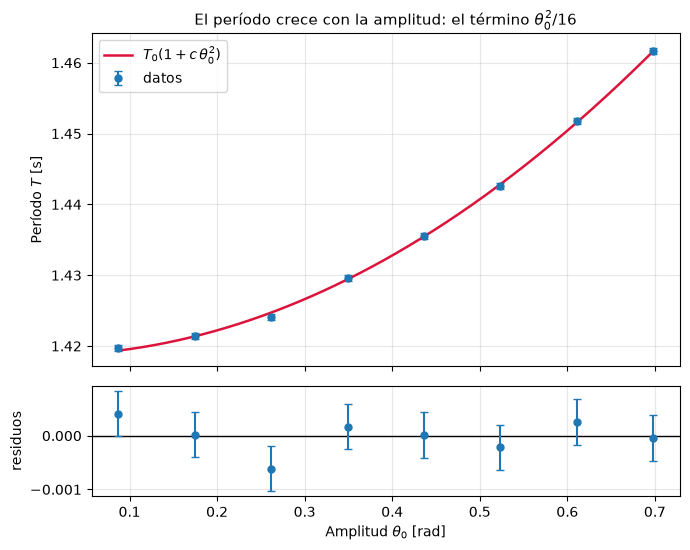

In [19]:
# ============ DATOS DE EJEMPLO — REEMPLAZAR POR LOS PROPIOS ============
T0_verdadero = 1.4185
T_theta = T0_verdadero * (1 + theta**2/16) * (1 + rng.normal(0, 3e-4, len(theta)))
sigma_T_theta = np.full(len(theta), max(sigma_T_photogate, 3e-4*T0_verdadero))
# =======================================================================

def modelo_amplitud(th, T0, coef):
    return T0 * (1 + coef * th**2)

popt_a, pcov_a = curve_fit(modelo_amplitud, theta, T_theta,
                           sigma=sigma_T_theta, absolute_sigma=True, p0=[1.4, 0.06])
perr_a = np.sqrt(np.diag(pcov_a))

print("T0   =", reportar(popt_a[0], perr_a[0], 's'))
print("coef =", reportar(popt_a[1], perr_a[1], ''), "   (predicción: 1/16 = 0,0625)")
print()
_ = compatibilidad(popt_a[1], perr_a[1], 1/16, 0.0, ('coeficiente medido', 'teórico 1/16'))

fig, _ = grafico_con_residuos(theta, T_theta, modelo_amplitud, popt_a, yerr=sigma_T_theta,
                              xlabel='Amplitud $\\theta_0$ [rad]', ylabel='Período $T$ [s]',
                              titulo='El período crece con la amplitud: el término $\\theta_0^2/16$',
                              etiqueta_modelo='$T_0(1 + c\\,\\theta_0^2)$')

Notá que acá ya usamos `curve_fit` **con** `sigma=` y `absolute_sigma=True`. Eso se explica en detalle
en el Colab 06; por ahora quedate con que ésa es la forma correcta de llamarlo cuando conocés tus
barras de error, y que el default de scipy **no** es ésa.

> ⚠️ **Cuidado experimental.** La amplitud **decae** mientras medís. Si tomás 20 períodos partiendo
> de 40°, al final ya no estás en 40°, y el $T$ que reportás es un promedio sobre amplitudes
> decrecientes: un sistemático que siempre va en la misma dirección. Para amplitudes grandes conviene
> medir pocos períodos y anotar la amplitud inicial **y** la final.
>
> **✏️ Ejercicio 4.4.** Estimá el error que introduce ese decaimiento. Si en 20 períodos la amplitud
> cae de 40° a 35°, ¿cuánto vale la diferencia entre el $T$ que medís y el $T(40°)$ que creés medir?
> ¿Es mayor o menor que tu $\sigma_T$?

---
## 8. Ejercicios ✏️

**4.5.** 📦 Recorrida completa con tus datos: extraé los períodos de tu archivo del photogate,
determiná $n$ con su incerteza, hacé el test de compatibilidad con 1/2, y reportá $g$. Incluí los dos
gráficos con residuos. Ésa es la Entrega corta 2.

**4.6.** Justificá por escrito, en dos oraciones, el criterio de flanco que elegiste. Después
rehacé el análisis con el otro flanco. ¿Cambia $T$? ¿Cambia su dispersión?

**4.7.** En la Sección 2.4 comparamos el piso de muestreo contra la dispersión observada. Con tus
datos, ¿cuál gana? Si gana el muestreo, ¿cuántas veces tendrías que bajar $f_s$ para que empatara con
la dispersión? Ese número te dice cuánta resolución temporal te está sobrando.

**4.8.** *(diseño)* Tenés que elegir siete longitudes entre 0,20 y 1,20 m. ¿Conviene espaciarlas
uniformemente o en escala logarítmica? Ajustá el exponente con las dos elecciones (simulá los datos)
y compará $\sigma_n$. Justificá la respuesta mirando dónde caen los puntos en el eje $\ln L$.

**4.9.** *(conceptual)* Si en vez de ajustar $\ln T$ vs. $\ln L$ ajustás $T^2$ vs. $L$ y obtenés un
buen ajuste, ¿demostraste que $n = 1/2$? Escribí por qué no, y qué es lo que efectivamente
demostraste.

**4.10.** Volvé al Colab 03, Sección 6. Ordená de menor a mayor incerteza los cuatro métodos de medir
un período que conocés a esta altura: cronometrar 1 oscilación, cronometrar 20, photogate 1 período,
photogate 20 períodos. ¿Cuál es el salto más grande, el de repetir o el de cambiar de instrumento?